# Environment check — the venv project

Question 8: the same check as the uv project's notebook, on the other
side of the comparison. With `venv` there is no `--with`: Jupyter has
to be installed *into* the environment before it can run.

```bash
source .venv/bin/activate
pip install jupyter
jupyter lab
```


## Which interpreter is this?

In [1]:
import sys

print(sys.executable)

~/Desktop/Etude/University-Coursework/Master/M1/S7/Programming/Python/TP1-environments/venv-and-pip/.venv/bin/python3


## The packages this exercise asked for

In [2]:
import matplotlib, requests

print('requests  ', requests.__version__)
print('matplotlib', matplotlib.__version__)

requests   2.34.2
matplotlib 3.11.1


## What installing Jupyter cost the requirements file

This is question 3's point, made concrete. Seven packages have been
asked for across the whole exercise — `requests`, `matplotlib`,
`pylint`, `mypy`, `types-requests`, `pytest` and now `jupyter`. Count
what is actually installed:

In [3]:
import subprocess

frozen = subprocess.run([sys.executable, '-m', 'pip', 'freeze'],
                        capture_output=True, text=True, check=True).stdout
installed = [line for line in frozen.splitlines() if line.strip()]
asked_for = ['requests', 'matplotlib', 'pylint', 'mypy', 'types-requests',
             'pytest', 'jupyter']
print(f'{len(asked_for)} packages asked for, {len(installed)} pinned lines')
print('nothing in the file says which are which')

7 packages asked for, 119 pinned lines
nothing in the file says which are which


## The exercise's own code, in the notebook

`meteo.py` sits next to this notebook, so the work from questions 1
to 3 is importable, and matplotlib draws into the page.

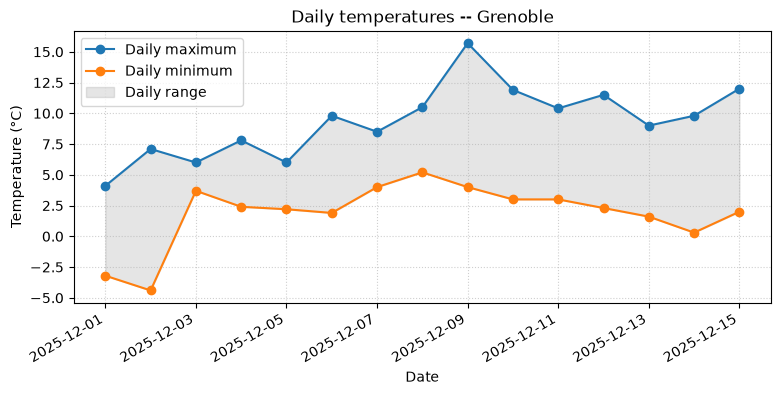

In [4]:
%matplotlib inline
from meteo import COORDINATES, query_open_meteo, plot_temperature

data = query_open_meteo(*COORDINATES['Grenoble'], '2025-12-01', '2025-12-15')
axes = plot_temperature(data, 'Grenoble')
axes.figure.set_size_inches(9, 4)